#  Transformer-Based Sentiment Analysis Models

As part of the advanced phase of this project, transformer-based language models were fine-tuned and evaluated for multi-class sentiment classification on the Amazon Reviews dataset.

The following transformer models were trained and evaluated for multi-class sentiment classification:

- **BERT Base (`bert-base-uncased`)** – A bidirectional transformer model that captures contextual information from both directions for accurate sentiment classification.

- **DistilRoBERTa (`distilroberta-base`)** – A lightweight and faster version of RoBERTa that delivers high performance with reduced computational cost.
```

In [3]:
import fasttext
import numpy as np
import pandas as pd
import re
import html as html_lib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

# Training settings
SEED = 42
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 192
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
OUTPUT_DIR = Path("outputs/amazon_distilroberta_sentiment")
VOCAB_SIZE = 30000
MAX_SEQUENCE_LENGTH = 128

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU when available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [8]:
df = pd.read_parquet("data/processed/reviews_after_preprocessing.parquet")

# Quick check
print(df.shape)       
print(df.columns)  

(674523, 18)
Index(['rating', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp',
       'helpful_vote', 'verified_purchase', 'review', 'sentiment',
       'char_length', 'word_count', 'sentence_count', 'year', 'month',
       'clean_review', 'languages', 'dl_review'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674523 entries, 0 to 674522
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             674523 non-null  int64         
 1   images             674523 non-null  object        
 2   asin               674523 non-null  object        
 3   parent_asin        674523 non-null  object        
 4   user_id            674523 non-null  object        
 5   timestamp          674523 non-null  datetime64[ns]
 6   helpful_vote       674523 non-null  int64         
 7   verified_purchase  674523 non-null  bool          
 8   review             674523 non-null  object        
 9   sentiment          674523 non-null  object        
 10  char_length        674523 non-null  int64         
 11  word_count         674523 non-null  int64         
 12  sentence_count     674523 non-null  int64         
 13  year               674523 non-null  int32   

In [10]:
df[['review','sentiment']]

,review,sentiment
0,Such a lovely scent but not overpowering. This...,Positive
1,Works great but smells a little weird. This pr...,Positive
2,"Yes! Smells good, feels great!",Positive
3,Synthetic feeling Felt synthetic,Negative
4,Pretty Color The polish was quiet thick and di...,Positive
...,...,...
674518,Four Stars Conditioner is great shampoo not a...,Positive
674519,Pretty Did not work! Used the whole bottle and...,Negative
674520,Great sunless tanner Product as expected. Ship...,Positive
674521,The Crown on top is a Ring!!! Not only is it a...,Positive


In [22]:
df.languages.value_counts()

languages
en    674523
Name: count, dtype: int64

In [23]:
df.sentiment.value_counts()

sentiment
Positive    480076
Negative    139832
Neutral      54615
Name: count, dtype: int64

In [11]:
# Remove HTML and links but preserve normal text, emojis, punctuation, and casing
def prepare_review(text):
    text = html_lib.unescape(str(text))
    text = BeautifulSoup(text, "html.parser").get_text(" ", strip=True)
    text = re.sub(r"(https?://\S+|www\.\S+)", " <URL> ", text)
    return re.sub(r"\s+", " ", text).strip()

# Keep only the raw review and its sentiment
data = df[["review", "sentiment"]].dropna().copy()
data["review"] = data["review"].map(prepare_review)
data = data[data["review"].str.len() > 0].reset_index(drop=True)

# Convert text labels into model labels
label_names = ["Negative", "Neutral", "Positive"]
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

data = data[data["sentiment"].isin(label2id)].copy()
data["label"] = data["sentiment"].map(label2id)

print(data["sentiment"].value_counts())
print("Rows used:", len(data))

sentiment
Positive    480076
Negative    139832
Neutral      54615
Name: count, dtype: int64
Rows used: 674523


In [23]:
data["label"].value_counts()

label
2    480076
0    139832
1     54615
Name: count, dtype: int64

In [12]:
# 80% train, 10% validation, 10% final test data
train_df, temp_df = train_test_split(
    data,
    test_size=0.20,
    stratify=data["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test: {len(test_df):,}")

Train: 539,618
Validation: 67,452
Test: 67,453


In [13]:
# RoBERTa tokenizer converts raw text into token IDs
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class AmazonReviewDataset(Dataset):
    def __init__(self, reviews, labels):
        self.reviews = reviews.tolist()
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoded = tokenizer(
            self.reviews[idx],
            truncation=True,
            max_length=MAX_LENGTH
        )
        encoded["labels"] = self.labels[idx]
        return encoded

# Pad reviews dynamically to the longest review in each batch
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

In [14]:
train_ds = AmazonReviewDataset(train_df["review"], train_df["label"])
val_ds = AmazonReviewDataset(val_df["review"], val_df["label"])
test_ds = AmazonReviewDataset(test_df["review"], test_df["label"])

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collator, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collator, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collator, num_workers=0, pin_memory=True
)

## Amazon Review Sentiment Classification Using Fine-Tuned DistilRoBERTa


This model classifies Amazon reviews into Negative, Neutral, and Positive sentiments.
It fine-tunes DistilRoBERTa, a pretrained Transformer model, using raw review text.
Only HTML tags and URLs are removed; emojis, punctuation, and spelling variations are retained.
Class weights help reduce bias toward the larger Positive class.
Model performance is evaluated using Accuracy and Macro F1-score.


In [49]:
# Load pretrained Transformer with 3 sentiment classes
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)

# disable cache during training
model.config.use_cache = False


# class-weighted loss for imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values
)

class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


# optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)


# learning-rate scheduler with warmup
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


# mixed precision training
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


# GPU optimization flags
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    print("GPU:", torch.cuda.get_device_name(0))
    print("AMP: Enabled")
    print("TF32: Enabled")


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
AMP: Enabled
TF32: Enabled


In [32]:
@torch.no_grad()
def evaluate(loader):
    model.eval()  # evaluation mode

    true_labels = []
    predictions = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        # move data to device
        labels = batch.pop("labels").to(device, non_blocking=True)
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        # forward pass
        logits = model(**batch).logits

        # predicted class
        preds = torch.argmax(logits, dim=1)

        # collect results on CPU
        true_labels.extend(labels.cpu().numpy())
        predictions.extend(preds.cpu().numpy())

    # metrics
    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average="macro", zero_division=0)

    return accuracy, macro_f1, true_labels, predictions


In [ ]:
# Train and save the model with the best validation macro F1
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_f1 = -1
patience = 2
bad_epochs = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in progress:
        labels = batch.pop("labels").to(device)
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(**batch).logits
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        progress.set_postfix(loss=f"{running_loss / (progress.n + 1):.4f}")

    val_accuracy, val_f1, _, _ = evaluate(val_loader)

    print(
        f"Epoch {epoch + 1} | "
        f"Validation Accuracy: {val_accuracy:.4f} | "
        f"Validation Macro F1: {val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        bad_epochs = 0
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print("✓ Best model saved.")
    else:
        bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

Epoch 1/3:   0%|          | 0/33727 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4216 [00:00<?, ?it/s]


Epoch 1/3
Train Loss:          0.4856
Validation Accuracy: 0.9109
Validation Macro F1: 0.7929


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved (Macro F1: 0.7929)
------------------------------------------------------------


...

Evaluating:   0%|          | 0/4216 [00:00<?, ?it/s]


Epoch 2/3
Train Loss:          0.4196
Validation Accuracy: 0.9134
Validation Macro F1: 0.8002


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Best model saved (Macro F1: 0.8002)
------------------------------------------------------------


Epoch 3/3:   0%|          | 0/33727 [00:00<?, ?it/s]

In [9]:
# Load the best saved model and evaluate it once on unseen test data
PARTIAL_DIR = Path("outputs/amazon_distilroberta_sentiment")

model = AutoModelForSequenceClassification.from_pretrained(
    PARTIAL_DIR
).to(device)

test_accuracy, test_f1, y_true, y_pred = evaluate(test_loader)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        digits=4,
        zero_division=0
    )
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4216 [00:00<?, ?it/s]

Test Accuracy: 0.9160
Test Macro F1: 0.8058
              precision    recall  f1-score   support

    Negative     0.8757    0.8937    0.8846     13983
     Neutral     0.5340    0.5989    0.5645      5462
    Positive     0.9780    0.9586    0.9682     48008

    accuracy                         0.9160     67453
   macro avg     0.7959    0.8171    0.8058     67453
weighted avg     0.9208    0.9160    0.9182     67453



In [18]:
# Predict sentiments for new raw Amazon reviews
@torch.no_grad()
def predict_sentiment(reviews):
    reviews = [prepare_review(review) for review in reviews]

    inputs = tokenizer(
        reviews,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    ).to(device)

    probabilities = torch.softmax(model(**inputs).logits, dim=1)
    predicted_ids = probabilities.argmax(dim=1).cpu().numpy()

    return pd.DataFrame({
        "review": reviews,
        "sentiment": [id2label[idx] for idx in predicted_ids],
        "confidence": probabilities.max(dim=1).values.cpu().numpy()
    })

predict_sentiment([
    "This product is absolutely amazing 😍",
    "It arrived broken and customer service was terrible.",
    "The quality is okay, but nothing special."
])

,review,sentiment,confidence
0,This product is absolutely amazing 😍,Positive,0.999564
1,It arrived broken and customer service was ter...,Negative,0.998862
2,"The quality is okay, but nothing special.",Neutral,0.980563


## Experiment 2: Fine-Tuned RoBERTa-base for Amazon Review Sentiment Classification
 RoBERTa-base is larger than DistilRoBERTa and may improve Neutral-class performance. A longer maximum sequence length preserves more information from detailed reviews.

In [41]:
MODEL_NAME = "roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 4
LEARNING_RATE = 1e-5
OUTPUT_DIR = Path("outputs/amazon_roberta_base_sentiment")

In [42]:
# Load the RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Recreate datasets because the maximum length has changed
train_ds = AmazonReviewDataset(train_df["review"], train_df["label"])
val_ds = AmazonReviewDataset(val_df["review"], val_df["label"])
test_ds = AmazonReviewDataset(test_df["review"], test_df["label"])

collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collator, num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collator, num_workers=0, pin_memory=True
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collator, num_workers=0, pin_memory=True
)

In [17]:
# Load pretrained RoBERTa with a new three-class classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)

# Keep class balancing for the imbalanced sentiment data
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values
)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

use_amp = device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("RoBERTa-base setup is ready.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa-base setup is ready.


C:\Users\jayas\AppData\Local\Temp\ipykernel_233228\2125131434.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [14]:
# Train and save the model with the best validation macro F1
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_f1 = -1
patience = 2
bad_epochs = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in progress:
        labels = batch.pop("labels").to(device)
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(**batch).logits
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        progress.set_postfix(loss=f"{running_loss / (progress.n + 1):.4f}")

    val_accuracy, val_f1, _, _ = evaluate(val_loader)

    print(
        f"Epoch {epoch + 1} | "
        f"Validation Accuracy: {val_accuracy:.4f} | "
        f"Validation Macro F1: {val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        bad_epochs = 0
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print("Best model saved.")
    else:
        bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

Epoch 1/4:   0%|          | 0/67453 [00:00<?, ?it/s]

C:\Users\jayas\AppData\Local\Temp\ipykernel_85064\4072366227.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  0%|          | 0/8432 [00:00<?, ?it/s]

Epoch 1 | Validation Accuracy: 0.9165 | Validation Macro F1: 0.7973


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved.


Epoch 3/4:   0%|          | 0/67453 [00:00<?, ?it/s]

C:\Users\jayas\AppData\Local\Temp\ipykernel_85064\4072366227.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


KeyboardInterrupt: 

### Training Interruption and Final Model Selection

#### Training Interruption

Training was manually stopped using `KeyboardInterrupt` because each epoch required more than four hours to complete and extended training caused laptop instability and kernel crashes.

The interruption occurred during a later epoch. The partial progress from that incomplete epoch was not used as the final model.

The best checkpoint from the completed Epoch 2 was already saved before training was interrupted. Therefore, stopping training did not affect the saved best model.

The messages related to widget display were notebook interface issues and did not affect model training or saved model weights.



In [4]:
PARTIAL_DIR = Path("outputs/amazon_roberta_base_sentiment")

model = AutoModelForSequenceClassification.from_pretrained(
    PARTIAL_DIR
).to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [15]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    true_labels = []
    predictions = []

    for batch in tqdm(loader, leave=False, desc="Validating"):
        labels = batch.pop("labels").to(device)
        inputs = {key: value.to(device) for key, value in batch.items()}

        logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=1)

        true_labels.extend(labels.cpu().numpy())
        predictions.extend(preds.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average="macro")

    return accuracy, macro_f1,predictions,true_labels


In [16]:
test_accuracy, test_macro_f1, y_pred, y_true = evaluate(
    model,
    test_loader,
    device
)
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"],
        digits=4,
        zero_division=0
    )
)

Validating:   0%|          | 0/4216 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Negative     0.8669    0.9154    0.8905     13983
     Neutral     0.5585    0.5646    0.5615      5462
    Positive     0.9788    0.9617    0.9702     48008

    accuracy                         0.9199     67453
   macro avg     0.8014    0.8139    0.8074     67453
weighted avg     0.9216    0.9199    0.9206     67453



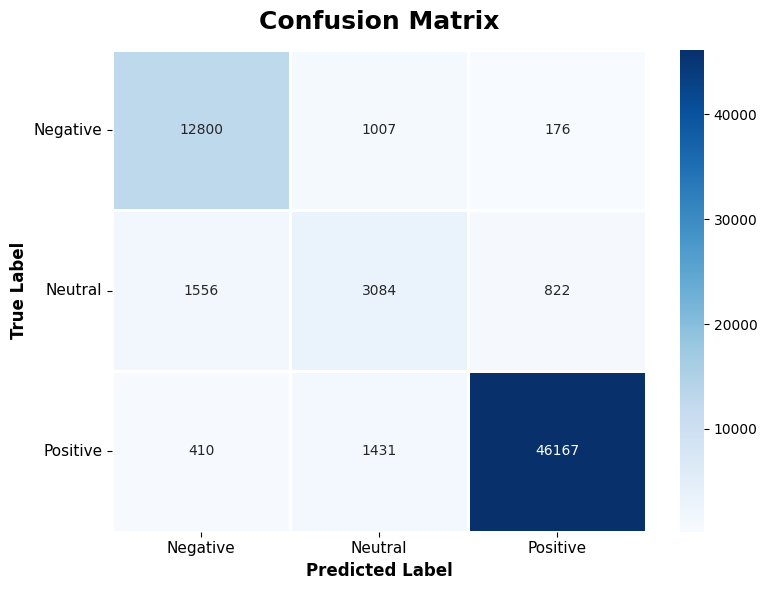

In [21]:
# Class labels
labels = ["Negative", "Neutral", "Positive"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor="white",
    cbar=True
)

plt.title(
    "Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

In [19]:
predict_sentiment([
    # Positive
    "This laptop is super fast n reliabel!", # 0
    "Amazing servise, I will definetly come again.", # 1
    "Movie was inspiering and beautifuly shot.", # 2

    # Negative
    "Worst product i ever buy, waste of mony.", # 3
    "Delivery late and pakage damage.", # 4
    "App keep crash, very frustating experiance.", # 5

    # Neutral
    "Phone works as expect, nothing extra.", # 6
    "Its ok, do the job but not impresive.", # 7
    "Taste is average, not too bad not great.", # 8

    # Mixed / Hard to classify
    "Design looks nice but build feel cheap.", # 9
    "Good featuers, but battery drain fast.", # 10
    "Support was polite but not solve my issue." # 11
])


,review,sentiment,confidence
0,This laptop is super fast n reliabel!,Positive,0.999255
1,"Amazing servise, I will definetly come again.",Positive,0.999540
2,Movie was inspiering and beautifuly shot.,Positive,0.999410
3,"Worst product i ever buy, waste of mony.",Negative,0.998266
4,Delivery late and pakage damage.,Negative,0.986298
5,"App keep crash, very frustating experiance.",Negative,0.988504
6,"Phone works as expect, nothing extra.",Positive,0.977891
7,"Its ok, do the job but not impresive.",Neutral,0.975007
8,"Taste is average, not too bad not great.",Neutral,0.983144
9,Design looks nice but build feel cheap.,Neutral,0.948766


# Final Model Selection

BERT-base was selected as the final sentiment-classification model because it achieved the best practical balance between model performance and available computing resources.

- Test Accuracy: approximately 0.9199%
- Test Macro F1-score: approximately 0.8074%
- Training Epochs Completed: 2

Although additional epochs or larger Transformer models may improve performance, they require substantially more training time and caused system instability. Therefore, the BERT-base model trained for two epochs was finalized as the most suitable model for this project.